# Support Vector Machine

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns; sns.set()

Working with perfectly Linear Dataset

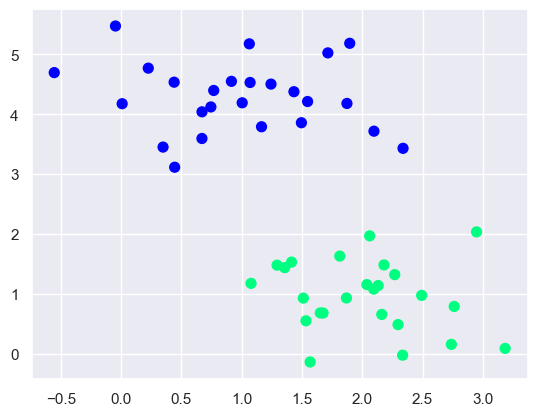

In [3]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')

In [ ]:
from sklearn.svm import SVC
model = SVC(kernel='linear', C=1)
model.fit(X, y)

SVC(C=1, kernel='linear')

In [5]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

## 1. Why Maximize the Margin?
- Maximizing the margin = maximizing **generalization**.
- A wider margin means the model is **less sensitive to small variations** in new/unseen data.
- This is the core reason SVMs often outperform other classifiers in **high-dimensional spaces**.
- Mathematically, margin = **2 / ||w||**, so maximizing margin ↔ minimizing ||w||.


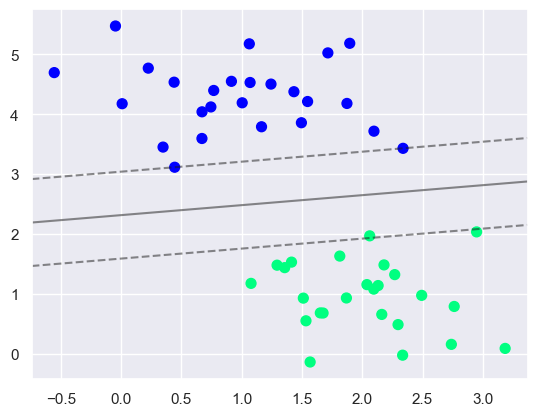

In [6]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model);

## 2. Support Vectors — The Only Points That Matter
- Only the data points **closest to the decision boundary** (support vectors) define the hyperplane.
- All other training points are **irrelevant** to the final model — this is called **sparsity**.
- If you remove a non-support-vector point, the decision boundary **does not change**.
- This sparsity makes SVMs **memory efficient** and interpretable post-training.


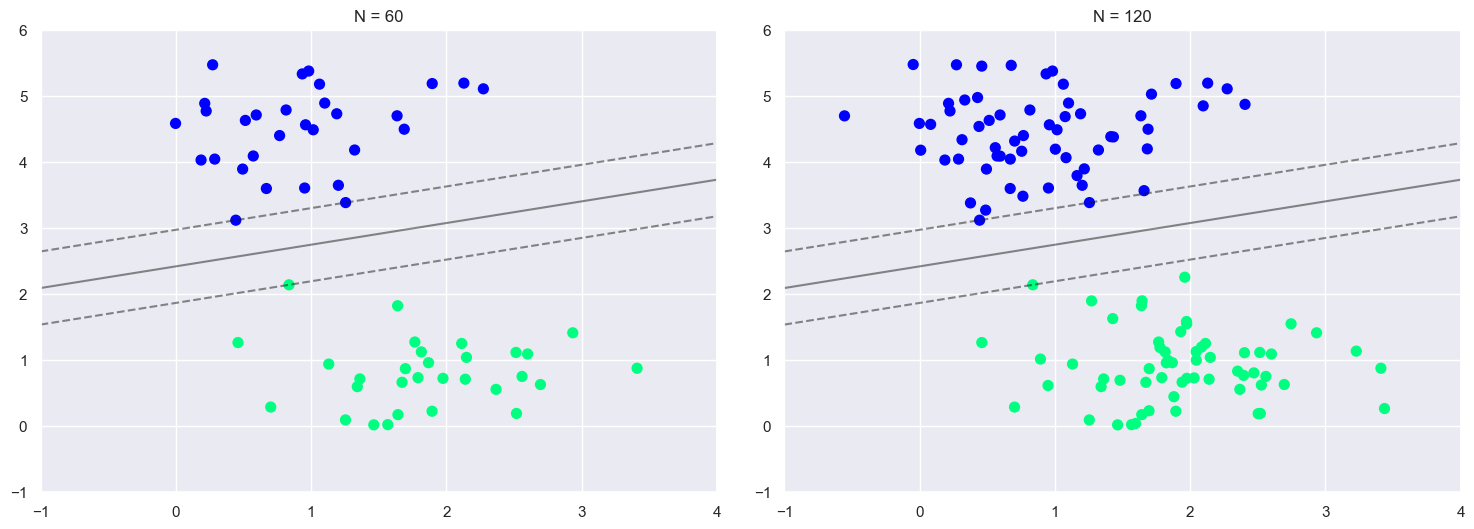

In [7]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)
    
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

## 3. Hard Margin vs Soft Margin
| | Hard Margin | Soft Margin |
|---|---|---|
| Assumption | Perfectly linearly separable | Allows some misclassifications |
| Slack Variables | None | ξᵢ ≥ 0 |
| Real-world use | Rarely used | Almost always used |
| Risk | Fails if data has noise/outliers | Controlled by parameter **C** |


Working with almost Linear dataset

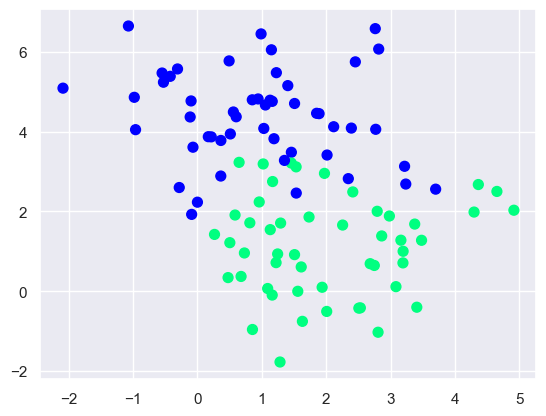

In [8]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter');

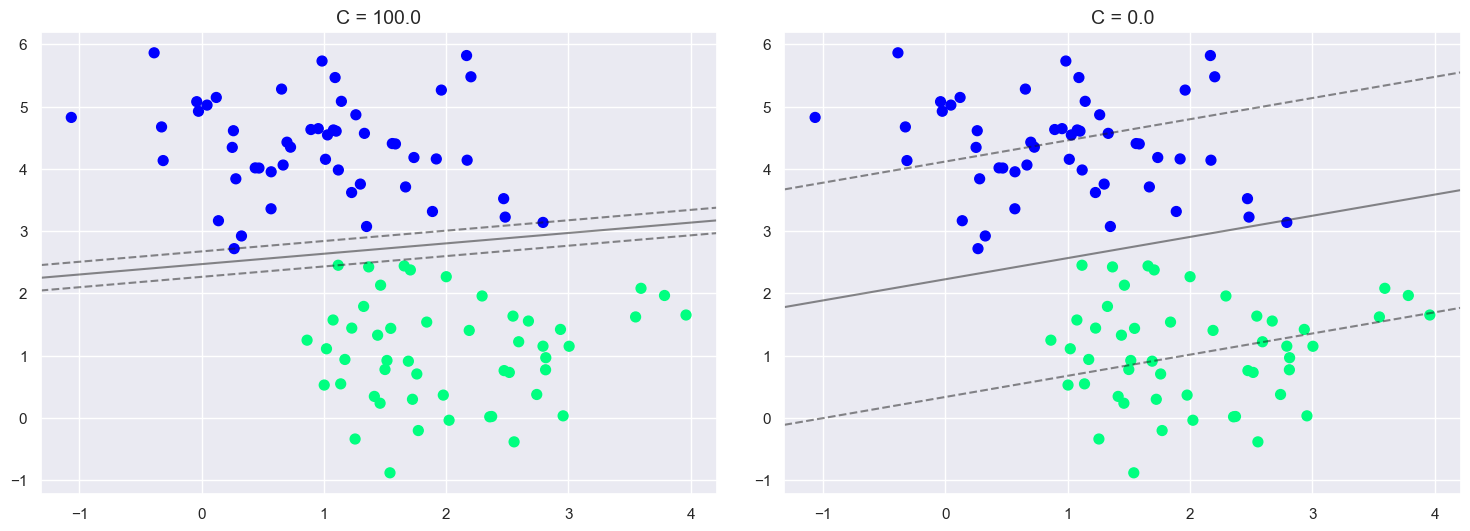

In [9]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [100.0, 0.01]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

## 4. The Parameter C 
- **C** controls the trade-off between **margin width** and **classification error**.
- **High C** → Penalizes misclassifications heavily → Smaller margin → Risk of **overfitting**.
- **Low C** → Tolerates more errors → Larger margin → Risk of **underfitting**.
- *Interview tip:* C in SVM is analogous to **inverse of regularization strength** in logistic regression (i.e., C = 1/λ).


## 9. Overfitting Signals in SVM
- Too many support vectors → model is **memorizing noise**, not learning structure.
- Very high training accuracy but poor validation accuracy → classic overfit signal.
- Fix: lower **C**, use simpler kernel, apply **k-fold cross-validation**.
